In [1]:
!pip install -q arabic_reshaper python-bidi wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 7.9 MB/s eta 0:00:00


In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display

import nltk
from nltk.stem.isri import ISRIStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

RANDOM_STATE = 42
sns.set_style("whitegrid")

def ar(text):
    return get_display(arabic_reshaper.reshape(str(text)))

In [4]:
df = pd.read_csv("summarizdataset.csv")
df = df.rename(columns={
    "text": "original_text",
    "type": "category",
    "Processed Text": "processed_text",
    "summarizer": "summary"
})
print(df.shape)
df.head()

(8378, 4)


,original_text,category,processed_text,summary
0,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...,culture,اشرف رئيس الجمهوريه الباجي قايد السبسي اليوم ب...,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...
1,"\nتحصل كتاب ""المصحف وقراءاته"" الذي ألفه باحثون...",culture,تحصل كتاب المصحف وقراءاته الفه باحثون تونسيون ...,"\nتحصل كتاب ""المصحف وقراءاته"" الذي ألفه باحثون..."
2,\nاحتضن جناح تونس في القرية الدولية للأفلام بم...,culture,احتضن جناح تونس القريه الدوليه للافلام بمدينه ...,تونس حاضرة من جهة أخرى ستكون تونس حاضرة في قائ...
3,\nشهدت برلين أمس الجمعة افتتاح مسجد فريد من نو...,culture,شهدت برلين الجمعه افتتاح مسجد فريد نوعه الاقل ...,واستأجرت صاحبة المشروع المحامية والكاتبة سيران...
4,\nنعت وزارة الشّؤون الثّقافيّة المنشد الصّوفي ...,culture,نعت وزاره المنشد عز بن محمود انتقل جوار يوم تن...,\nنعت وزارة الشّؤون الثّقافيّة المنشد الصّوفي ...


In [5]:
print(df.info())
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   original_text   8378 non-null   object
 1   category        8378 non-null   object
 2   processed_text  8378 non-null   object
 3   summary         8378 non-null   object
dtypes: object(4)
memory usage: 261.9+ KB
None

Missing values:
 original_text     0
category          0
processed_text    0
summary           0
dtype: int64

Duplicate rows: 298


/tmp/ipykernel_4285/3567975109.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y="category", data=df, order=order, palette="viridis")
/tmp/ipykernel_4285/3567975109.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([ar(t.get_text()) for t in ax.get_yticklabels()])


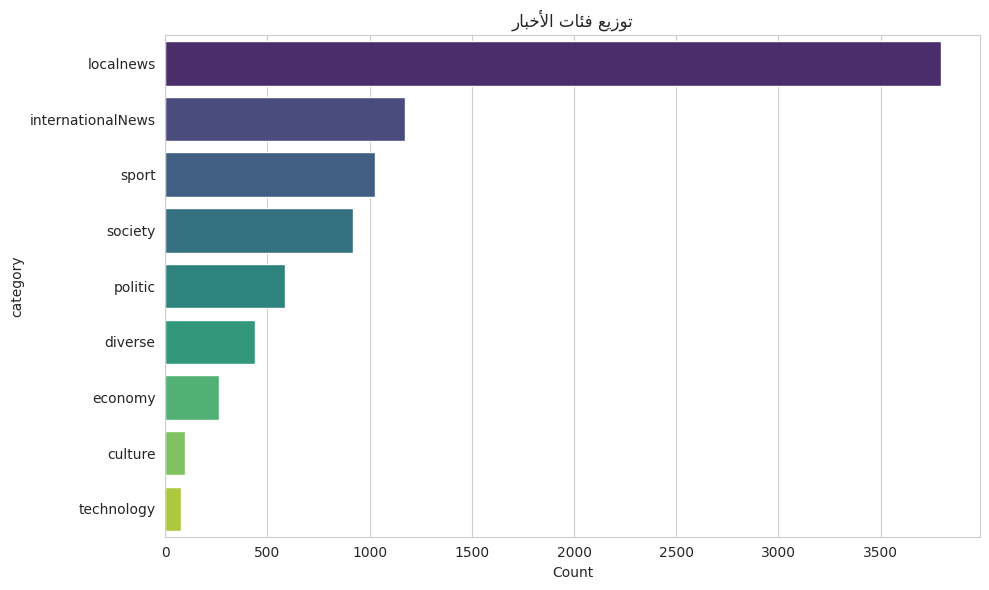

In [6]:
plt.figure(figsize=(10, 6))
order = df["category"].value_counts().index
ax = sns.countplot(y="category", data=df, order=order, palette="viridis")
ax.set_yticklabels([ar(t.get_text()) for t in ax.get_yticklabels()])
plt.title(ar("توزيع فئات الأخبار"))
plt.xlabel("Count")
plt.tight_layout()
plt.show()

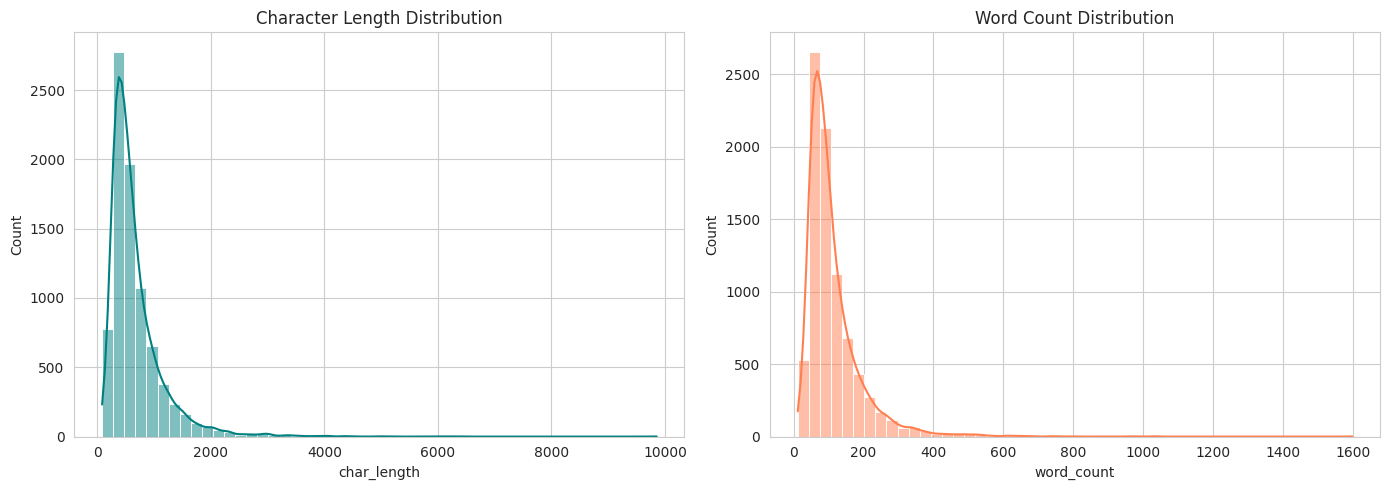

,char_length,word_count
count,8378.000000,8378.000000
mean,663.660062,111.752805
std,491.505431,81.588635
min,82.000000,12.000000
25%,366.000000,62.000000
50%,524.500000,89.000000
75%,793.000000,133.000000
max,9854.000000,1597.000000


In [7]:
df["char_length"] = df["original_text"].str.len()
df["word_count"] = df["original_text"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["char_length"], bins=50, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Character Length Distribution")
sns.histplot(df["word_count"], bins=50, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Word Count Distribution")
plt.tight_layout()
plt.show()

df[["char_length", "word_count"]].describe()

/tmp/ipykernel_4285/1628786634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="word_count", y="category", data=df, order=order, palette="mako")
/tmp/ipykernel_4285/1628786634.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([ar(t.get_text()) for t in ax.get_yticklabels()])


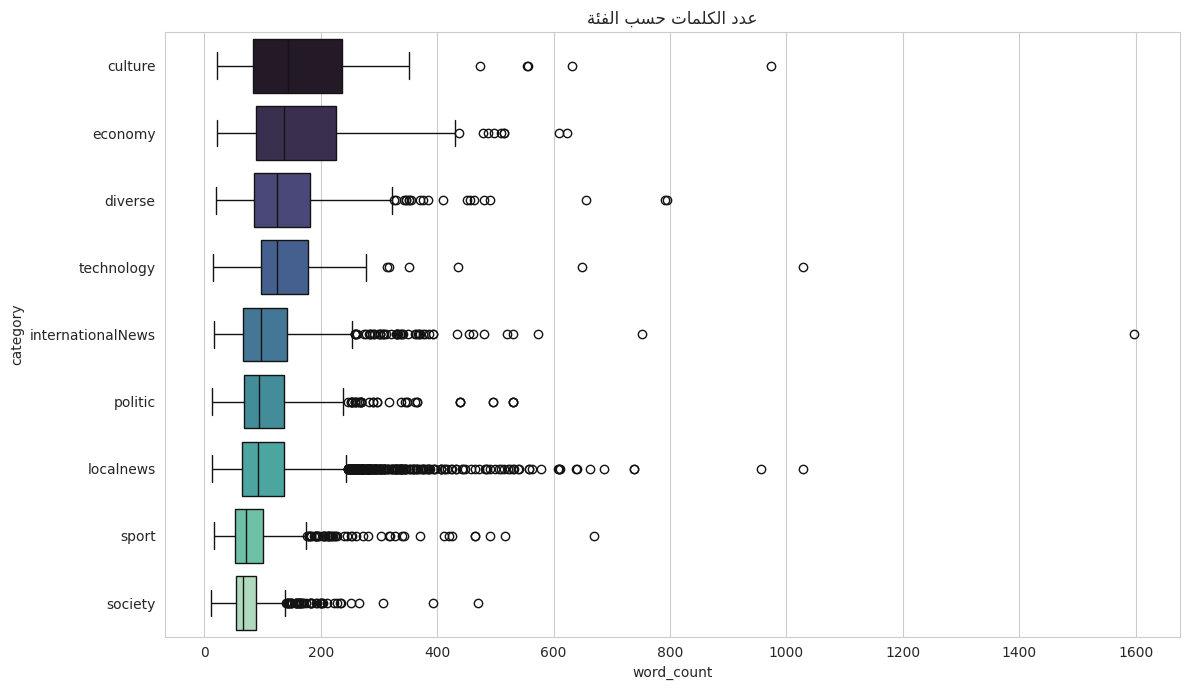

In [8]:
plt.figure(figsize=(12, 7))
order = df.groupby("category")["word_count"].median().sort_values(ascending=False).index
ax = sns.boxplot(x="word_count", y="category", data=df, order=order, palette="mako")
ax.set_yticklabels([ar(t.get_text()) for t in ax.get_yticklabels()])
plt.title(ar("عدد الكلمات حسب الفئة"))
plt.tight_layout()
plt.show()

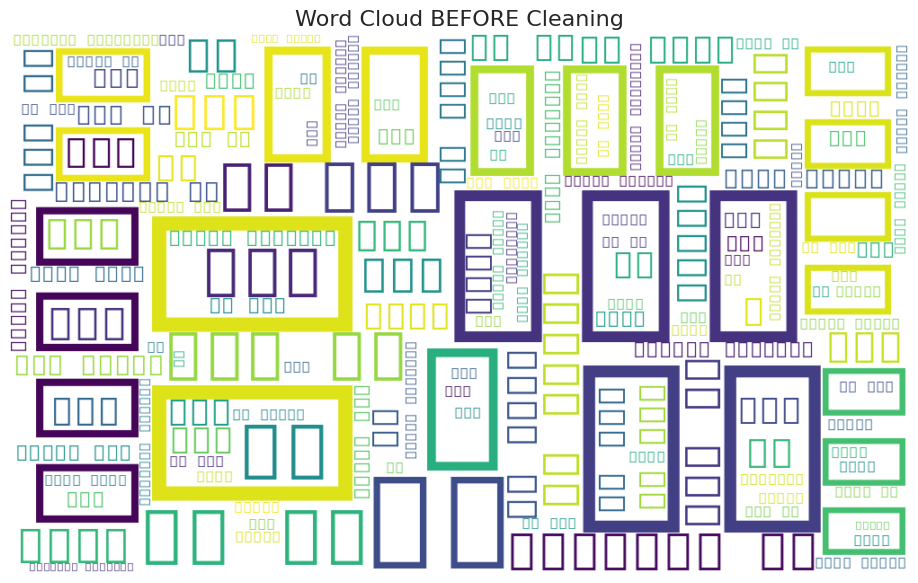

In [9]:
raw_sample = " ".join(df["original_text"].astype(str).sample(min(3000, len(df)), random_state=42))
reshaped = arabic_reshaper.reshape(raw_sample)
bidi_text = get_display(reshaped)

wc_before = WordCloud(width=1000, height=600, background_color="white", max_words=150).generate(bidi_text)

plt.figure(figsize=(12, 7))
plt.imshow(wc_before, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud BEFORE Cleaning", fontsize=16)
plt.show()

In [10]:
before = len(df)
df = df.drop_duplicates(subset=["original_text"])
df = df.dropna(subset=["original_text", "category"])
df = df[df["word_count"] >= 10].reset_index(drop=True)
print(f"Removed {before - len(df)} rows -> {len(df)} rows remaining")

Removed 323 rows -> 8055 rows remaining


In [11]:
def remove_diacritics(text):
    return re.sub(r"[\u064B-\u0652]", "", str(text))

df["step1_no_diacritics"] = df["original_text"].apply(remove_diacritics)
df[["original_text", "step1_no_diacritics"]].head(2)

,original_text,step1_no_diacritics
0,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...
1,"\nتحصل كتاب ""المصحف وقراءاته"" الذي ألفه باحثون...","\nتحصل كتاب ""المصحف وقراءاته"" الذي ألفه باحثون..."


In [12]:
def remove_tatweel(text):
    return re.sub(r"\u0640", "", text)

df["step2_no_tatweel"] = df["step1_no_diacritics"].apply(remove_tatweel)

In [13]:
def normalize_arabic(text):
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ة", "ه", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    return text

df["step3_normalized"] = df["step2_no_tatweel"].apply(normalize_arabic)
df[["step2_no_tatweel", "step3_normalized"]].head(2)

,step2_no_tatweel,step3_normalized
0,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...,\nاشرف رييس الجمهوريه الباجي قايد السبسي اليوم...
1,"\nتحصل كتاب ""المصحف وقراءاته"" الذي ألفه باحثون...","\nتحصل كتاب ""المصحف وقراءاته"" الذي الفه باحثون..."


In [14]:
def keep_arabic_only(text):
    text = re.sub(r"[^\u0621-\u064A\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["step4_arabic_only"] = df["step3_normalized"].apply(keep_arabic_only)
df[["step3_normalized", "step4_arabic_only"]].head(2)

,step3_normalized,step4_arabic_only
0,\nاشرف رييس الجمهوريه الباجي قايد السبسي اليوم...,اشرف رييس الجمهوريه الباجي قايد السبسي اليوم ب...
1,"\nتحصل كتاب ""المصحف وقراءاته"" الذي الفه باحثون...",تحصل كتاب المصحف وقراءاته الذي الفه باحثون تون...


In [15]:
df["tokens_raw"] = df["step4_arabic_only"].apply(lambda x: x.split())
df["tokens_raw"].head()

,tokens_raw
0,"[اشرف, رييس, الجمهوريه, الباجي, قايد, السبسي, ..."
1,"[تحصل, كتاب, المصحف, وقراءاته, الذي, الفه, باح..."
2,"[احتضن, جناح, تونس, في, القريه, الدوليه, للافل..."
3,"[شهدت, برلين, امس, الجمعه, افتتاح, مسجد, فريد,..."
4,"[نعت, وزاره, الشوون, الثقافيه, المنشد, الصوفي,..."


In [16]:
nltk_arabic_stopwords = set(stopwords.words('arabic'))

manual_stopwords = set('''
من الى إلى عن على في و او أو ثم بل لا ما لم لن إن ان اذا إذا كل بعض غير سوى حتى
هذا هذه هذان هاتان ذلك تلك هؤلاء الذي التي الذين اللاتي اللواتي هو هي هم هن انت انتم انتن
انا نحن كان كانت كانوا يكون تكون سيكون قد لقد لدى عند بين بعد قبل فوق تحت امام أمام خلال
مع دون بلا ضد نحو حول لكل لكن لكنه لكنها ايضا أيضا كما كأن مثل حيث اين أين كيف لماذا متى
له لها لهم لهن لك لكم لكن به بها بهم فيه فيها منه منها عليه عليها إليه إليها
'''.split())

all_stopwords = nltk_arabic_stopwords | manual_stopwords
print("Total stopwords:", len(all_stopwords))

df["tokens_no_stopwords"] = df["tokens_raw"].apply(lambda tokens: [w for w in tokens if w not in all_stopwords])

Total stopwords: 729


In [17]:
df["tokens_no_stopwords"] = df["tokens_no_stopwords"].apply(lambda tokens: [w for w in tokens if len(w) > 2])

In [18]:
stemmer = ISRIStemmer()

df["tokens_stemmed"] = df["tokens_no_stopwords"].apply(lambda tokens: [stemmer.stem(w) for w in tokens])

# قارن قبل وبعد الـ stemming
sample_idx = 2
print("Before stemming:", df["tokens_no_stopwords"].iloc[sample_idx][:10])
print("After stemming :", df["tokens_stemmed"].iloc[sample_idx][:10])

Before stemming: ['احتضن', 'جناح', 'تونس', 'القريه', 'الدوليه', 'للافلام', 'بمدينه', 'الفرنسيه', 'تستضيف', 'الدوره']
After stemming : ['حضن', 'جنح', 'ونس', 'قره', 'دول', 'فلم', 'بمد', 'رنس', 'تضف', 'دور']


In [19]:
df["clean_text"] = df["tokens_stemmed"].apply(lambda tokens: " ".join(tokens))
df["clean_token_count"] = df["tokens_stemmed"].apply(len)

df = df[df["clean_token_count"] >= 5].reset_index(drop=True)
print("Final shape:", df.shape)
df[["original_text", "clean_text"]].head()

Final shape: (8055, 15)


,original_text,clean_text
0,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...,شرف ريس جمهور بجي قيد سبس اليوم قصر قرطاج علي ...
1,"\nتحصل كتاب ""المصحف وقراءاته"" الذي ألفه باحثون...",حصل كتب صحف وقراءاته الف بحث ونس تخصص علي جيز ...
2,\nاحتضن جناح تونس في القرية الدولية للأفلام بم...,حضن جنح ونس قره دول فلم بمد رنس تضف دور سبع هر...
3,\nشهدت برلين أمس الجمعة افتتاح مسجد فريد من نو...,شهد برل امس جمع فتح سجد فرد نوع علي اقل علي ست...
4,\nنعت وزارة الشّؤون الثّقافيّة المنشد الصّوفي ...,نعت وزر شون ثقف نشد صوف دين حمد نقل الي جور رب...


In [20]:
i = 2
print("1) Original       :", df['original_text'].iloc[i][:150])
print("2) No diacritics  :", df['step1_no_diacritics'].iloc[i][:150])
print("3) No tatweel     :", df['step2_no_tatweel'].iloc[i][:150])
print("4) Normalized     :", df['step3_normalized'].iloc[i][:150])
print("5) Arabic only    :", df['step4_arabic_only'].iloc[i][:150])
print("6) Final (stemmed):", df['clean_text'].iloc[i][:150])

1) Original       : 
احتضن جناح تونس في القرية الدولية للأفلام بمدينة "كان" الفرنسية التي تستضيف الدورة السبعين لمهرجان كان السينمائي، لقاء جمع المدير العام للمركز الوطني
2) No diacritics  : 
احتضن جناح تونس في القرية الدولية للأفلام بمدينة "كان" الفرنسية التي تستضيف الدورة السبعين لمهرجان كان السينمائي، لقاء جمع المدير العام للمركز الوطني
3) No tatweel     : 
احتضن جناح تونس في القرية الدولية للأفلام بمدينة "كان" الفرنسية التي تستضيف الدورة السبعين لمهرجان كان السينمائي، لقاء جمع المدير العام للمركز الوطني
4) Normalized     : 
احتضن جناح تونس في القريه الدوليه للافلام بمدينه "كان" الفرنسيه التي تستضيف الدوره السبعين لمهرجان كان السينمايي، لقاء جمع المدير العام للمركز الوطني
5) Arabic only    : احتضن جناح تونس في القريه الدوليه للافلام بمدينه كان الفرنسيه التي تستضيف الدوره السبعين لمهرجان كان السينمايي لقاء جمع المدير العام للمركز الوطني للس
6) Final (stemmed): حضن جنح ونس قره دول فلم بمد رنس تضف دور سبع هرج ينم لقء جمع دير عام ركز وطن سين صور فتح خرط سول ركز رنس سين قدم تفق بعث صندوق

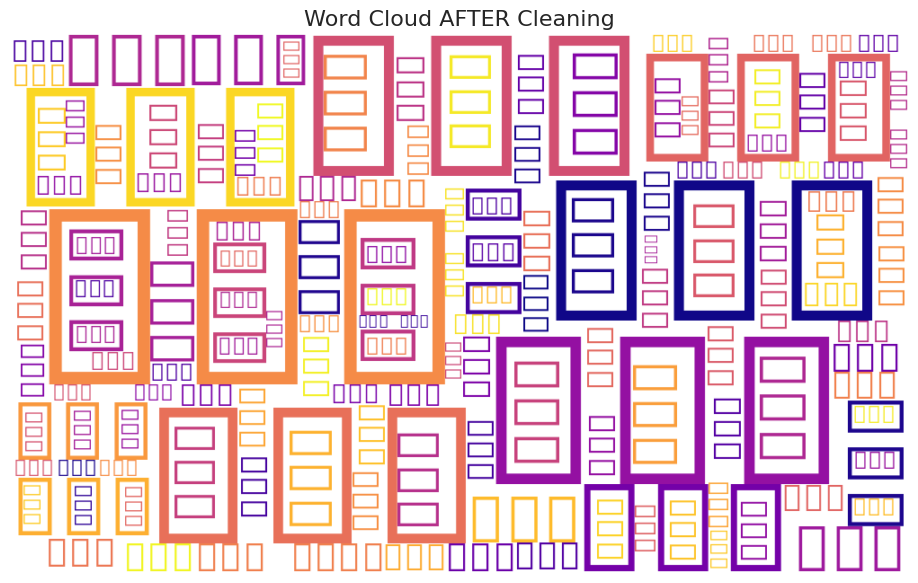

In [21]:
clean_sample = " ".join(df["clean_text"].sample(min(3000, len(df)), random_state=42))
reshaped = arabic_reshaper.reshape(clean_sample)
bidi_text = get_display(reshaped)

wc_after = WordCloud(width=1000, height=600, background_color="white", max_words=150, colormap='plasma').generate(bidi_text)

plt.figure(figsize=(12, 7))
plt.imshow(wc_after, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud AFTER Cleaning", fontsize=16)
plt.show()

/tmp/ipykernel_4285/2388665464.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=[ar(w) for w in words], palette="flare")


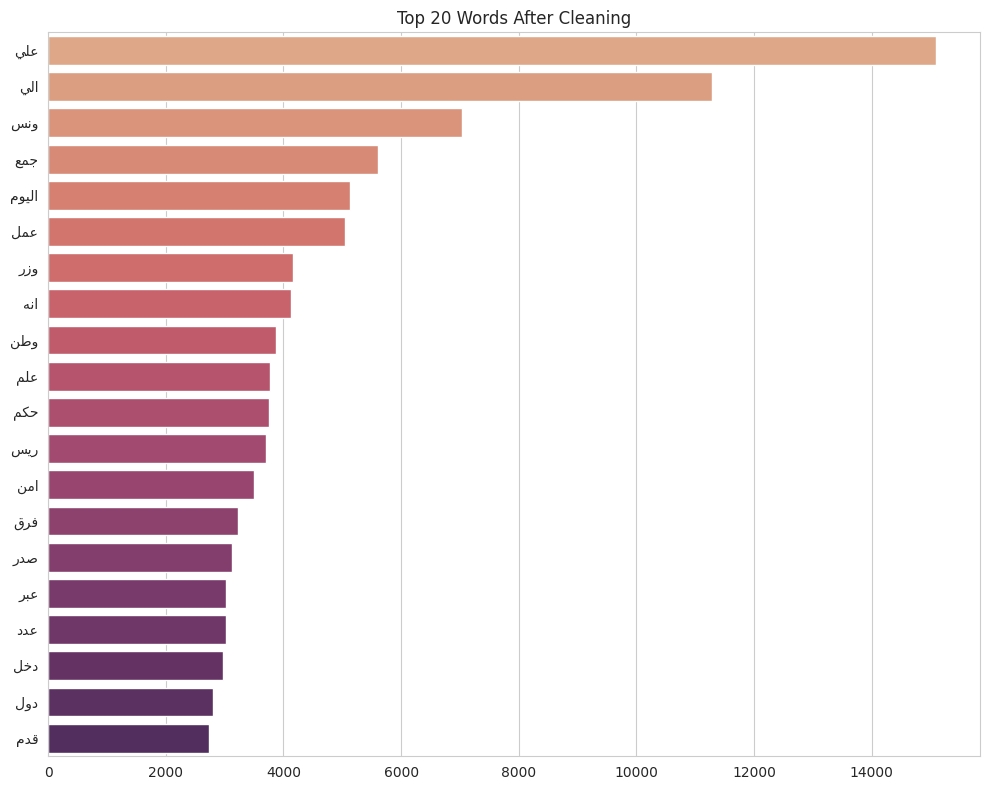

In [22]:
all_words = sum(df["tokens_stemmed"], [])
freq = Counter(all_words).most_common(20)
words, counts = zip(*freq)

plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=[ar(w) for w in words], palette="flare")
plt.title("Top 20 Words After Cleaning")
plt.tight_layout()
plt.show()

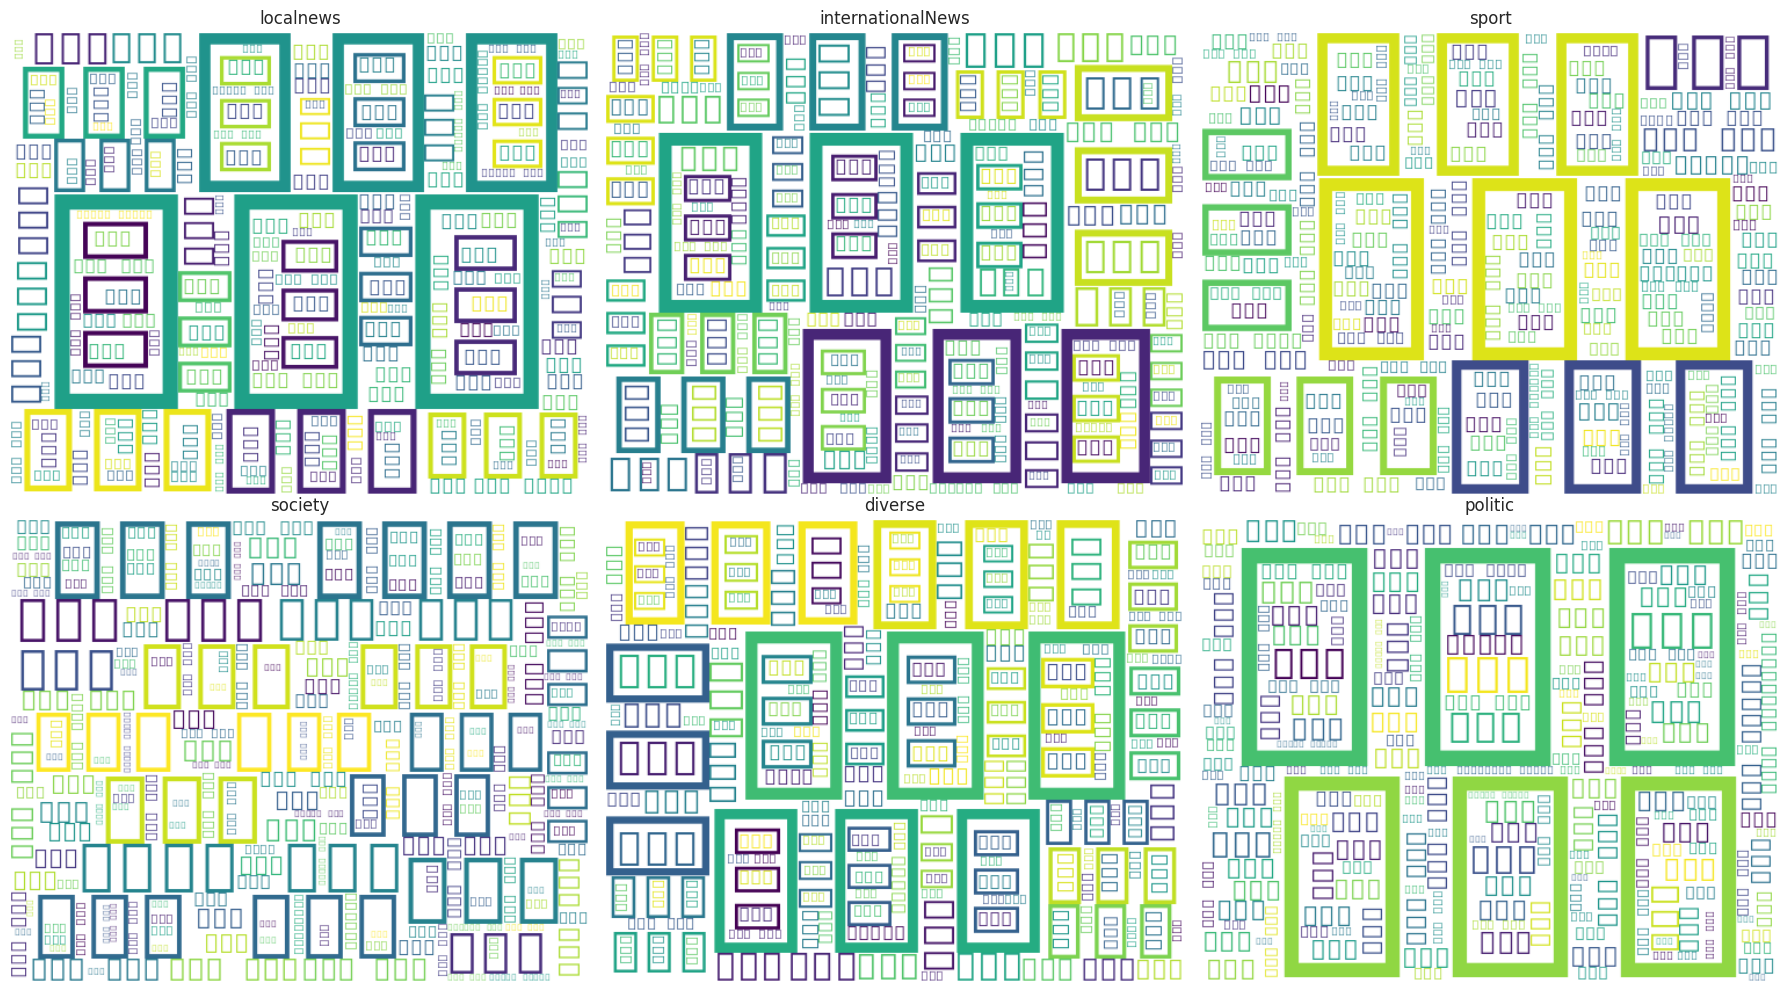

In [23]:
categories = df["category"].value_counts().index[:6]  # أكبر 6 فئات
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):
    cat_text = " ".join(df[df["category"] == cat]["clean_text"].sample(
        min(1000, (df["category"] == cat).sum()), random_state=42))
    reshaped = arabic_reshaper.reshape(cat_text)
    bidi_text = get_display(reshaped)
    wc = WordCloud(width=500, height=400, background_color="white").generate(bidi_text)
    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(ar(cat))
    axes[i].axis("off")

plt.tight_layout()
plt.show()

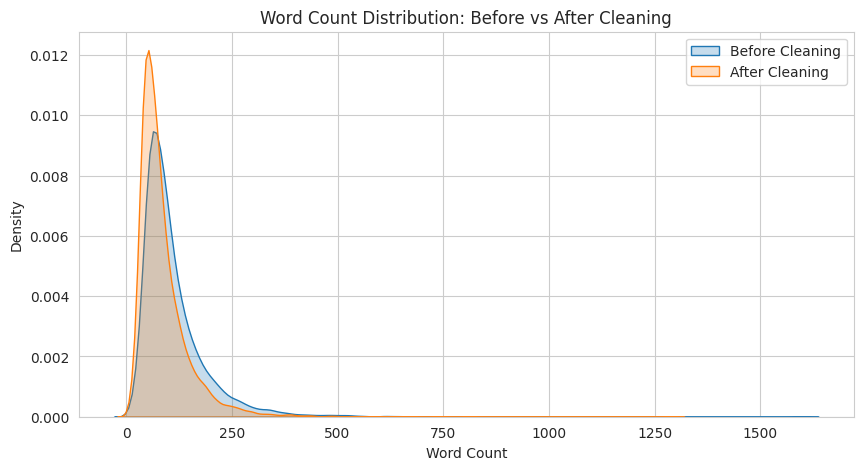

In [24]:
before_after = pd.DataFrame({
    'Before Cleaning': df['word_count'],
    'After Cleaning': df['clean_token_count']
})

plt.figure(figsize=(10, 5))
sns.kdeplot(before_after['Before Cleaning'], label='Before Cleaning', fill=True)
sns.kdeplot(before_after['After Cleaning'], label='After Cleaning', fill=True)
plt.title('Word Count Distribution: Before vs After Cleaning')
plt.xlabel('Word Count')
plt.legend()
plt.show()

تقسيم train/test + TF-IDF

In [25]:
le = LabelEncoder()
df["category_encoded"] = le.fit_transform(df["category"])
num_classes = len(le.classes_)
print(dict(zip(le.classes_, range(num_classes))))

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_text"], df["category_encoded"],
    test_size=0.2, random_state=42, stratify=df["category_encoded"]
)

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)
print("TF-IDF shape:", X_train_tfidf.shape, X_test_tfidf.shape)

{'culture': 0, 'diverse': 1, 'economy': 2, 'internationalNews': 3, 'localnews': 4, 'politic': 5, 'society': 6, 'sport': 7, 'technology': 8}
TF-IDF shape: (6444, 20000) (1611, 20000)


SVM

In [26]:
svm_model = LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE)
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {svm_accuracy:.4f}")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

SVM Accuracy: 0.8051
                   precision    recall  f1-score   support

          culture       0.71      0.79      0.75        19
          diverse       0.75      0.73      0.74        86
          economy       0.70      0.69      0.69        51
internationalNews       0.86      0.88      0.87       232
        localnews       0.84      0.78      0.81       745
          politic       0.54      0.65      0.59        79
          society       0.63      0.75      0.68       182
            sport       0.98      0.98      0.98       203
       technology       0.80      0.86      0.83        14

         accuracy                           0.81      1611
        macro avg       0.76      0.79      0.77      1611
     weighted avg       0.81      0.81      0.81      1611



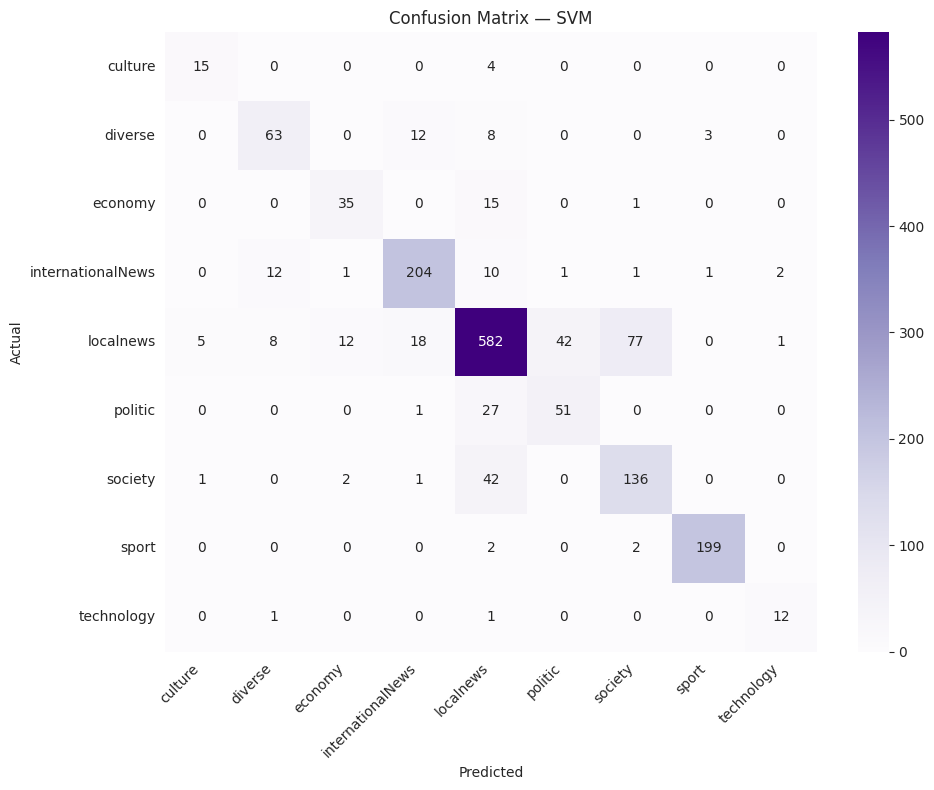

In [27]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[ar(c) for c in le.classes_], yticklabels=[ar(c) for c in le.classes_])
plt.title("Confusion Matrix — SVM")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Random Forest

In [28]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=50, class_weight="balanced",
                                    random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Accuracy: 0.7610
                   precision    recall  f1-score   support

          culture       0.71      0.26      0.38        19
          diverse       0.91      0.50      0.65        86
          economy       0.94      0.31      0.47        51
internationalNews       0.83      0.72      0.77       232
        localnews       0.71      0.87      0.79       745
          politic       0.67      0.30      0.42        79
          society       0.65      0.65      0.65       182
            sport       0.96      0.96      0.96       203
       technology       1.00      0.36      0.53        14

         accuracy                           0.76      1611
        macro avg       0.82      0.55      0.62      1611
     weighted avg       0.77      0.76      0.75      1611



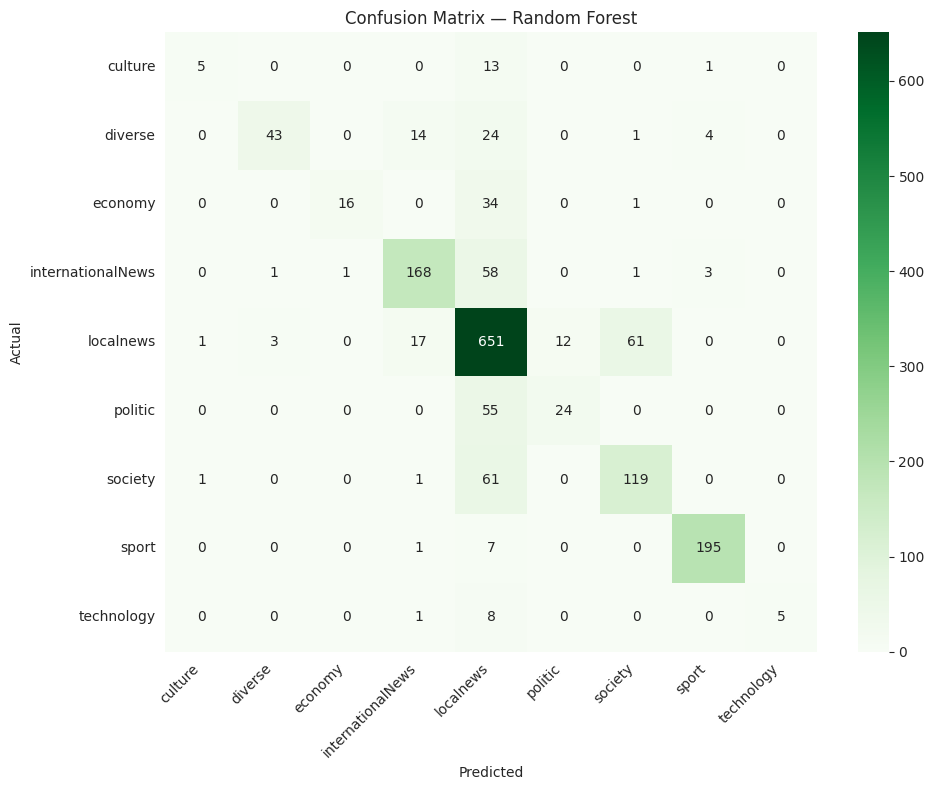

In [29]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=[ar(c) for c in le.classes_], yticklabels=[ar(c) for c in le.classes_])
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_4285/2566729728.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[top_idx], y=[ar(feature_names[i]) for i in top_idx], palette="crest")


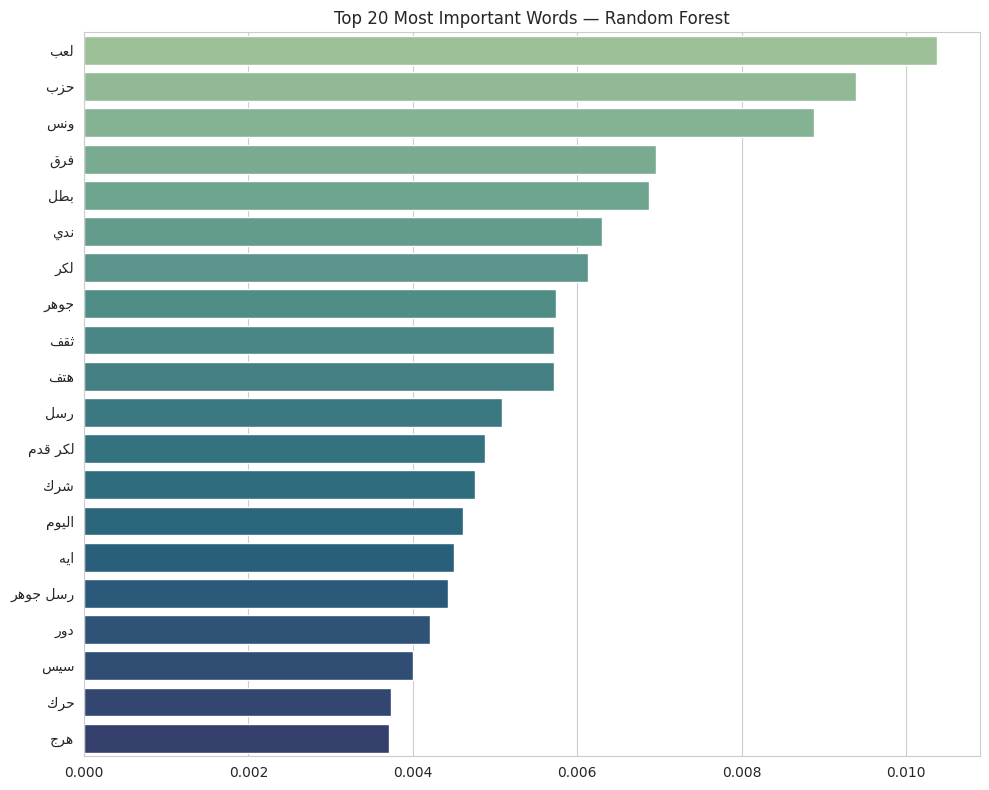

In [30]:
importances = rf_model.feature_importances_
feature_names = tfidf.get_feature_names_out()
top_idx = importances.argsort()[-20:][::-1]

plt.figure(figsize=(10, 8))
sns.barplot(x=importances[top_idx], y=[ar(feature_names[i]) for i in top_idx], palette="crest")
plt.title("Top 20 Most Important Words — Random Forest")
plt.tight_layout()
plt.show()

Neural Network

In [31]:
VOCAB_SIZE = 20000
EMBEDDING_DIM = 100
MAX_LEN = 150
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

In [32]:
cnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    Conv1D(filters=128, kernel_size=5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
cnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = cnn_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.15,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 192ms/step - accuracy: 0.4555 - loss: 1.7067 - val_accuracy: 0.4478 - val_loss: 1.4729
Epoch 2/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 146ms/step - accuracy: 0.6078 - loss: 1.2339 - val_accuracy: 0.6949 - val_loss: 0.9253
Epoch 3/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/step - accuracy: 0.7110 - loss: 0.8930 - val_accuracy: 0.7198 - val_loss: 0.7636
Epoch 4/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - accuracy: 0.7632 - loss: 0.7036 - val_accuracy: 0.7342 - val_loss: 0.6918
Epoch 5/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 142ms/step - accuracy: 0.8063 - loss: 0.5616 - val_accuracy: 0.7622 - val_loss: 0.6487
Epoch 6/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - accuracy: 0.8446 - loss: 0.4438 - val_accuracy: 0.7611 - val_loss: 0.6432
Epoch 7/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 136ms/step - accuracy: 0.8895 - loss: 0.3391 - val_accuracy: 0.7518 - val_loss: 0.6913
Epoch 8/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - accuracy: 0.9146 - loss: 0.2574 - val_accu

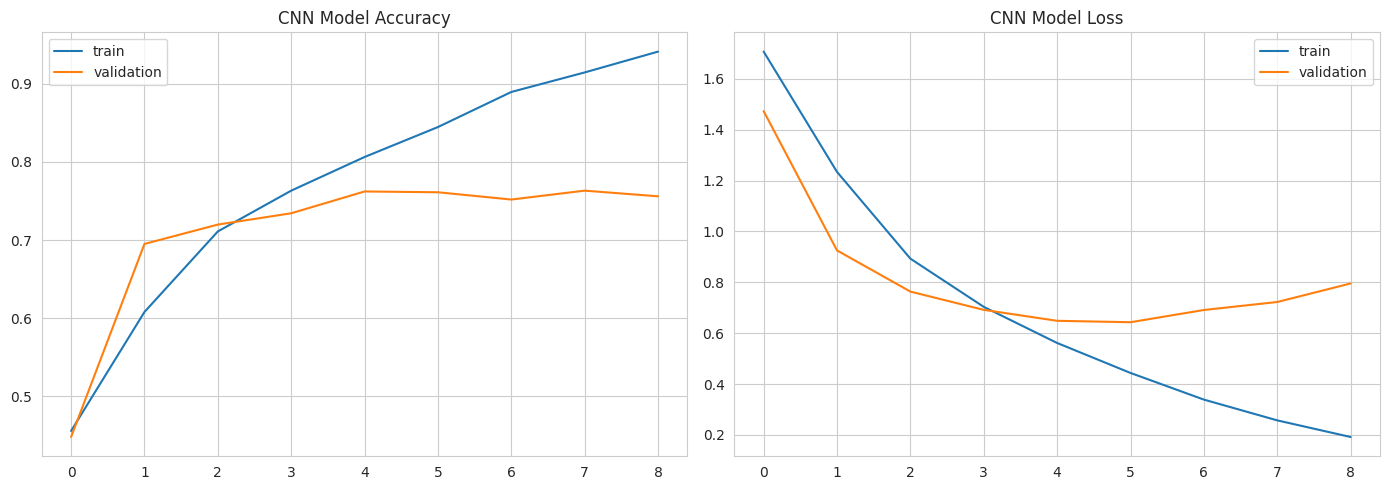

CNN Test Accuracy: 0.7430


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_title("CNN Model Accuracy")
axes[0].legend()
axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_title("CNN Model Loss")
axes[1].legend()
plt.tight_layout()
plt.show()

cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_pad, y_test_cat, verbose=0)
print(f"CNN Test Accuracy: {cnn_accuracy:.4f}")

/tmp/ipykernel_4285/3446783818.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=final_comparison, palette="rocket")


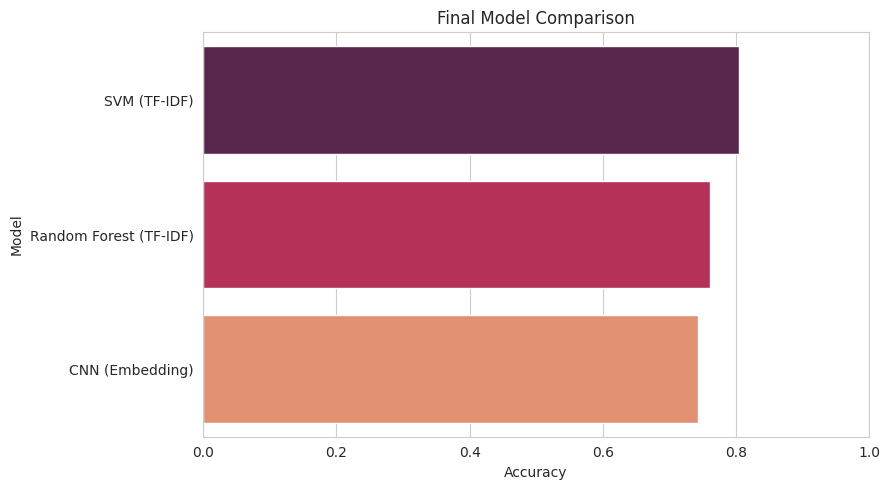

,Model,Accuracy
0,SVM (TF-IDF),0.805090
1,Random Forest (TF-IDF),0.761018
2,CNN (Embedding),0.743017


In [35]:
final_comparison = pd.DataFrame({
    "Model": ["SVM (TF-IDF)", "Random Forest (TF-IDF)", "CNN (Embedding)"],
    "Accuracy": [svm_accuracy, rf_accuracy, cnn_accuracy]
}).sort_values("Accuracy", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x="Accuracy", y="Model", data=final_comparison, palette="rocket")
plt.title("Final Model Comparison")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

final_comparison

In [36]:
df["clean_text_no_stem"] = df["tokens_no_stopwords"].apply(lambda tokens: " ".join(tokens))

X_train_text2, X_test_text2, y_train2, y_test2 = train_test_split(
    df["clean_text_no_stem"], df["category_encoded"],
    test_size=0.2, random_state=42, stratify=df["category_encoded"]
)

tfidf2 = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
X_train_tfidf2 = tfidf2.fit_transform(X_train_text2)
X_test_tfidf2 = tfidf2.transform(X_test_text2)

svm_model2 = LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE)
svm_model2.fit(X_train_tfidf2, y_train2)

y_pred_svm2 = svm_model2.predict(X_test_tfidf2)
svm_accuracy2 = accuracy_score(y_test2, y_pred_svm2)

print(f"SVM WITHOUT stemming accuracy: {svm_accuracy2:.4f}")
print(f"SVM WITH stemming accuracy:    {svm_accuracy:.4f}")

SVM WITHOUT stemming accuracy: 0.8063
SVM WITH stemming accuracy:    0.8051


In [37]:
tfidf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=30000, min_df=2)

X_train_char = tfidf_char.fit_transform(X_train_text2)
X_test_char = tfidf_char.transform(X_test_text2)

print("Char TF-IDF shape:", X_train_char.shape)

svm_char = LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE)
svm_char.fit(X_train_char, y_train2)

y_pred_char = svm_char.predict(X_test_char)
svm_char_accuracy = accuracy_score(y_test2, y_pred_char)

print(f"SVM + Char N-grams accuracy: {svm_char_accuracy:.4f}")
print(f"SVM + Word N-grams accuracy: {svm_accuracy2:.4f}")
print(classification_report(y_test2, y_pred_char, target_names=le.classes_))

Char TF-IDF shape: (6444, 30000)
SVM + Char N-grams accuracy: 0.8026
SVM + Word N-grams accuracy: 0.8063
                   precision    recall  f1-score   support

          culture       0.78      0.95      0.86        19
          diverse       0.79      0.70      0.74        86
          economy       0.62      0.73      0.67        51
internationalNews       0.84      0.91      0.88       232
        localnews       0.85      0.76      0.80       745
          politic       0.55      0.71      0.62        79
          society       0.62      0.76      0.68       182
            sport       0.98      0.97      0.98       203
       technology       0.80      0.86      0.83        14

         accuracy                           0.80      1611
        macro avg       0.76      0.81      0.78      1611
     weighted avg       0.81      0.80      0.81      1611



In [38]:
!pip install -q rouge-score networkx

  Preparing metadata (setup.py) ... done


In [39]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

def split_sentences(text):
    text = str(text).strip()
    sentences = re.split(r'(?<=[.!؟\n])\s+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 15]
    return sentences

# تجربة سريعة
test_sentences = split_sentences(df['original_text'].iloc[2])
print(f"عدد الجمل: {len(test_sentences)}")
for s in test_sentences[:3]:
    print("-", s[:100])

عدد الجمل: 7
- احتضن جناح تونس في القرية الدولية للأفلام بمدينة "كان" الفرنسية التي تستضيف الدورة السبعين لمهرجان ك
- وأوضح الخراط في تصريح أنه سيتم الشروع في تفعيل هذه الإتفاقية التي وقّعت في شهر فيفري الفارط بمناسبة 
- التعاون من "جحا" وقال مدير المركز الوطني للسينما والصورة إن "التعاون الثنائي بين البلدين في المجال ا


In [40]:
def textrank_summarize(text, num_sentences=2):
    sentences = split_sentences(text)

    if len(sentences) <= num_sentences:
        return " ".join(sentences)

    # تحويل الجمل لأرقام بـ TF-IDF (على مستوى الجملة)
    vectorizer = TfidfVectorizer()
    try:
        sentence_vectors = vectorizer.fit_transform(sentences)
    except ValueError:
        return " ".join(sentences[:num_sentences])

    # بناء مصفوفة التشابه بين كل جملتين
    similarity_matrix = cosine_similarity(sentence_vectors)

    # بناء الـ graph وتشغيل PageRank
    graph = nx.from_numpy_array(similarity_matrix)
    scores = nx.pagerank(graph)

    # اختيار أعلى الجمل سكور، مع الحفاظ على ترتيبها الأصلي في النص
    ranked_idx = sorted(scores, key=scores.get, reverse=True)[:num_sentences]
    ranked_idx = sorted(ranked_idx)  # ترتيب زي ما هي في النص الأصلي

    summary = " ".join([sentences[i] for i in ranked_idx])
    return summary

In [41]:
sample_idx = 2
generated = textrank_summarize(df['original_text'].iloc[sample_idx], num_sentences=2)

print("النص الأصلي:\n", df['original_text'].iloc[sample_idx][:400])
print("\nالملخص المولّد (TextRank):\n", generated)
print("\nالملخص الجاهز في الداتا:\n", df['summary'].iloc[sample_idx])

النص الأصلي:
 
احتضن جناح تونس في القرية الدولية للأفلام بمدينة "كان" الفرنسية التي تستضيف الدورة السبعين لمهرجان كان السينمائي، لقاء جمع المدير العام للمركز الوطني للسينما والصورة، فتحي الخراط ومسؤولين بالمركز الفرنسي للسينما لتقديم إتفاقية بعث صندوق إنتاج مشترك تونسي فرنسي لتمويل الأفلام.
وأوضح الخراط في تصريح أنه سيتم الشروع في تفعيل هذه الإتفاقية التي وقّعت في شهر فيفري الفارط بمناسبة زيارة وزيرة الثقافة وا

الملخص المولّد (TextRank):
 احتضن جناح تونس في القرية الدولية للأفلام بمدينة "كان" الفرنسية التي تستضيف الدورة السبعين لمهرجان كان السينمائي، لقاء جمع المدير العام للمركز الوطني للسينما والصورة، فتحي الخراط ومسؤولين بالمركز الفرنسي للسينما لتقديم إتفاقية بعث صندوق إنتاج مشترك تونسي فرنسي لتمويل الأفلام. تونس حاضرة من جهة أخرى ستكون تونس حاضرة في قائمة الترشحات لجوائز النقاد السنوية التي بعثها مركز السينما العربية ضمن فعاليات مهرجان كان في دورته السبعين.

الملخص الجاهز في الداتا:
 تونس حاضرة من جهة أخرى ستكون تونس حاضرة في قائمة الترشحات لجوائز النقاد السنوية التي بعثها مركز الس

In [42]:
SAMPLE_SIZE_SUMM = 300
summ_sample = df.sample(n=SAMPLE_SIZE_SUMM, random_state=42).reset_index(drop=True)

summ_sample['generated_summary'] = summ_sample['original_text'].apply(
    lambda x: textrank_summarize(x, num_sentences=2)
)

summ_sample[['summary', 'generated_summary']].head()

,summary,generated_summary
0,\nتدور اليوم عملية سحب القرعة الخاصة بمرحلة ال...,تدور اليوم عملية سحب القرعة الخاصة بمرحلة التت...
1,وشدد رئيس الحكومة على ضرورة تكوين جيل جديد من ...,وشدد رئيس الحكومة على ضرورة تكوين جيل جديد من ...
2,وأضاف طوبال أن 37 نائبا صوتوا إثر ذلك على احتر...,أفاد سفيان طوبال في تصريح إعلامي اليوم السبت، ...
3,وأضافت أن الدعوة العامة للمظاهرة التي ستجري غ...,"من جهتها أكدت امنة مرناقي رئيسة تنسيقية ""مانيش..."
4,\nأعلن الفرنسي باسكال جانان عن إنسحابه من مهام...,أعلن الفرنسي باسكال جانان عن إنسحابه من مهامه ...


In [43]:
SAMPLE_SIZE_SUMM = 300
summ_sample = df.sample(n=SAMPLE_SIZE_SUMM, random_state=42).reset_index(drop=True)

summ_sample['generated_summary'] = summ_sample['original_text'].apply(
    lambda x: textrank_summarize(x, num_sentences=2)
)

summ_sample[['summary', 'generated_summary']].head()

,summary,generated_summary
0,\nتدور اليوم عملية سحب القرعة الخاصة بمرحلة ال...,تدور اليوم عملية سحب القرعة الخاصة بمرحلة التت...
1,وشدد رئيس الحكومة على ضرورة تكوين جيل جديد من ...,وشدد رئيس الحكومة على ضرورة تكوين جيل جديد من ...
2,وأضاف طوبال أن 37 نائبا صوتوا إثر ذلك على احتر...,أفاد سفيان طوبال في تصريح إعلامي اليوم السبت، ...
3,وأضافت أن الدعوة العامة للمظاهرة التي ستجري غ...,"من جهتها أكدت امنة مرناقي رئيسة تنسيقية ""مانيش..."
4,\nأعلن الفرنسي باسكال جانان عن إنسحابه من مهام...,أعلن الفرنسي باسكال جانان عن إنسحابه من مهامه ...


In [44]:
SAMPLE_SIZE_SUMM = 300
summ_sample = df.sample(n=SAMPLE_SIZE_SUMM, random_state=42).reset_index(drop=True)

summ_sample['generated_summary'] = summ_sample['original_text'].apply(
    lambda x: textrank_summarize(x, num_sentences=2)
)

summ_sample[['summary', 'generated_summary']].head()

,summary,generated_summary
0,\nتدور اليوم عملية سحب القرعة الخاصة بمرحلة ال...,تدور اليوم عملية سحب القرعة الخاصة بمرحلة التت...
1,وشدد رئيس الحكومة على ضرورة تكوين جيل جديد من ...,وشدد رئيس الحكومة على ضرورة تكوين جيل جديد من ...
2,وأضاف طوبال أن 37 نائبا صوتوا إثر ذلك على احتر...,أفاد سفيان طوبال في تصريح إعلامي اليوم السبت، ...
3,وأضافت أن الدعوة العامة للمظاهرة التي ستجري غ...,"من جهتها أكدت امنة مرناقي رئيسة تنسيقية ""مانيش..."
4,\nأعلن الفرنسي باسكال جانان عن إنسحابه من مهام...,أعلن الفرنسي باسكال جانان عن إنسحابه من مهامه ...


In [45]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

rouge1_scores, rouge2_scores, rougeL_scores = [], [], []

for _, row in summ_sample.iterrows():
    scores = scorer.score(row['summary'], row['generated_summary'])
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)

summ_sample['rouge1'] = rouge1_scores
summ_sample['rouge2'] = rouge2_scores
summ_sample['rougeL'] = rougeL_scores

print("Average ROUGE-1:", np.mean(rouge1_scores))
print("Average ROUGE-2:", np.mean(rouge2_scores))
print("Average ROUGE-L:", np.mean(rougeL_scores))

Average ROUGE-1: 0.24678134774511581
Average ROUGE-2: 0.1337142857142857
Average ROUGE-L: 0.24624457909240519


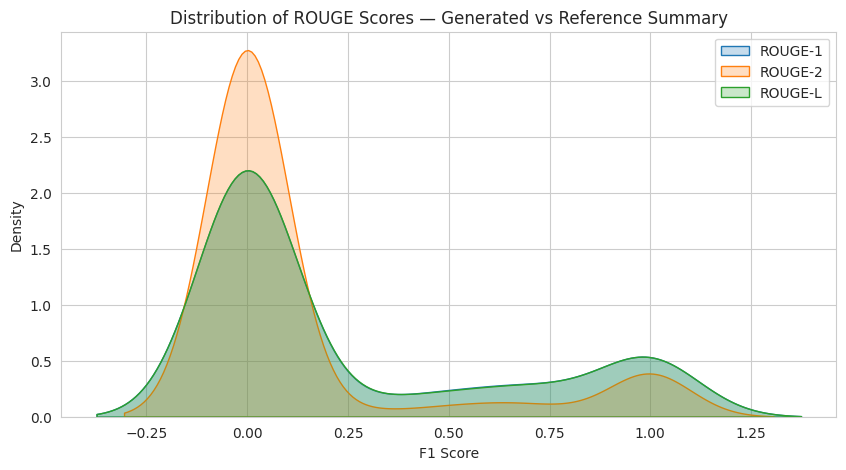

In [46]:
plt.figure(figsize=(10, 5))
sns.kdeplot(rouge1_scores, label='ROUGE-1', fill=True)
sns.kdeplot(rouge2_scores, label='ROUGE-2', fill=True)
sns.kdeplot(rougeL_scores, label='ROUGE-L', fill=True)
plt.title('Distribution of ROUGE Scores — Generated vs Reference Summary')
plt.xlabel('F1 Score')
plt.legend()
plt.show()

In [47]:
positive_words = set('''
جيد ممتاز رائع نجاح نجح تطور تقدم ايجابي انجاز انجازات فوز فاز انتصار سعيد سعاده
افضل تحسن تحسين ازدهار مشرق امل تفوق تميز انتعاش دعم مساعده سلام استقرار جميل
مبهر مشرف تفاؤل متفائل انفراج حل تعاون اتفاق مصالحه فرحه احتفال تكريم اشاده
'''.split())

negative_words = set('''
سيء ازمه أزمة فشل فشلت تراجع انخفاض خطر خطير كارثه عنف حرب صراع توتر قتل قتلى
وفاه وفيات ضحايا اصابه اصابات دمار خساره خسائر انهيار احتجاج احتجاجات اعتقال
اعتقالات ارهاب ارهابي فساد فقر بطاله ازمات غضب رفض اعدام اغتيال تفجير انفجار
مظاهره اضراب انقسام خلاف نزاع عقوبات حصار
'''.split())

def sentiment_score(text):
    words = str(text).split()
    pos = sum(1 for w in words if w in positive_words)
    neg = sum(1 for w in words if w in negative_words)
    if pos + neg == 0:
        return 0
    return (pos - neg) / (pos + neg)

def sentiment_label(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

In [48]:
df['sentiment_score'] = df['clean_text_no_stem'].apply(sentiment_score)
df['sentiment'] = df['sentiment_score'].apply(sentiment_label)

df['sentiment'].value_counts()

,count
sentiment,
Neutral,5563
Negative,1493
Positive,999


/tmp/ipykernel_4285/162948261.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment", data=df, order=["Positive", "Neutral", "Negative"],


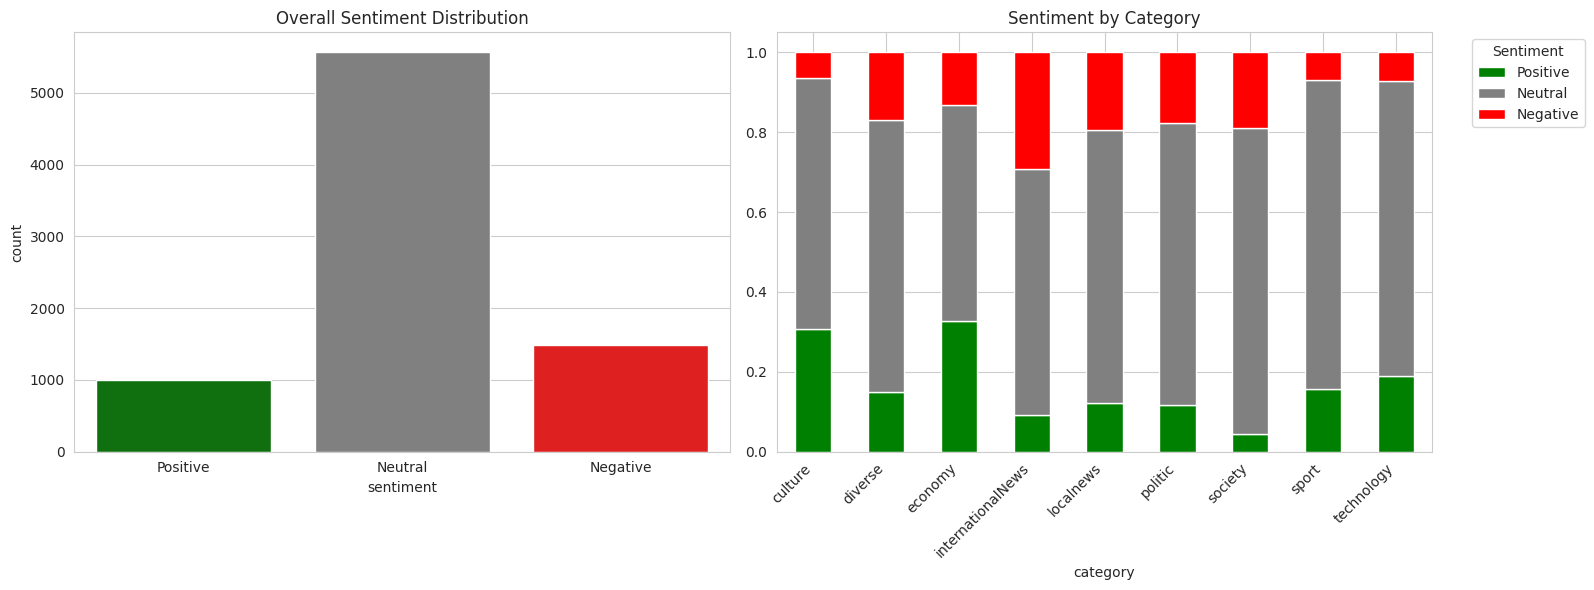

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x="sentiment", data=df, order=["Positive", "Neutral", "Negative"],
              palette={"Positive": "green", "Neutral": "gray", "Negative": "red"}, ax=axes[0])
axes[0].set_title("Overall Sentiment Distribution")

cross = pd.crosstab(df["category"], df["sentiment"], normalize="index")[["Positive", "Neutral", "Negative"]]
cross.plot(kind="bar", stacked=True, ax=axes[1], color=["green", "gray", "red"])
axes[1].set_xticklabels([ar(t) for t in cross.index], rotation=45, ha="right")
axes[1].set_title("Sentiment by Category")
axes[1].legend(title="Sentiment", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [51]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 37.8 MB/s eta 0:00:00


In [52]:
import gensim.corpora as corpora
from gensim.models import LdaModel

tokenized_docs = df["clean_text_no_stem"].apply(lambda x: x.split()).tolist()
dictionary = corpora.Dictionary(tokenized_docs)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

print("Dictionary size:", len(dictionary))

Dictionary size: 16467


In [53]:
NUM_TOPICS = 6

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,
    alpha="auto",
    per_word_topics=True
)

for idx, topic in lda_model.print_topics(num_words=8):
    words = [w.split("*")[1].strip().strip('"') for w in topic.split(" + ")]
    print(f"Topic {idx}: {' | '.join(words)}")

Topic 0: الوطني | الشركه | سوسه | وشارع | التونسيه | بلاغ | الساعه | الزواري
Topic 1: وقد | الجوهره | وفق | ولايه | مصدر | الوطني | انه | امس
Topic 2: بالمايه | كلم | درجه | الف | القطاع | مليون | بالشمال | ببقيه
Topic 3: تونس | رييس | الحكومه | انه | العام | تصريح | واضاف | وزير
Topic 4: النادي | رخص | القدم | المتحده | لكره | يوم | الساعه | حمدي
Topic 5: الصحه | التدخين | الاقلاع | وزاره | التونسيه | التونسي | انه | العلم


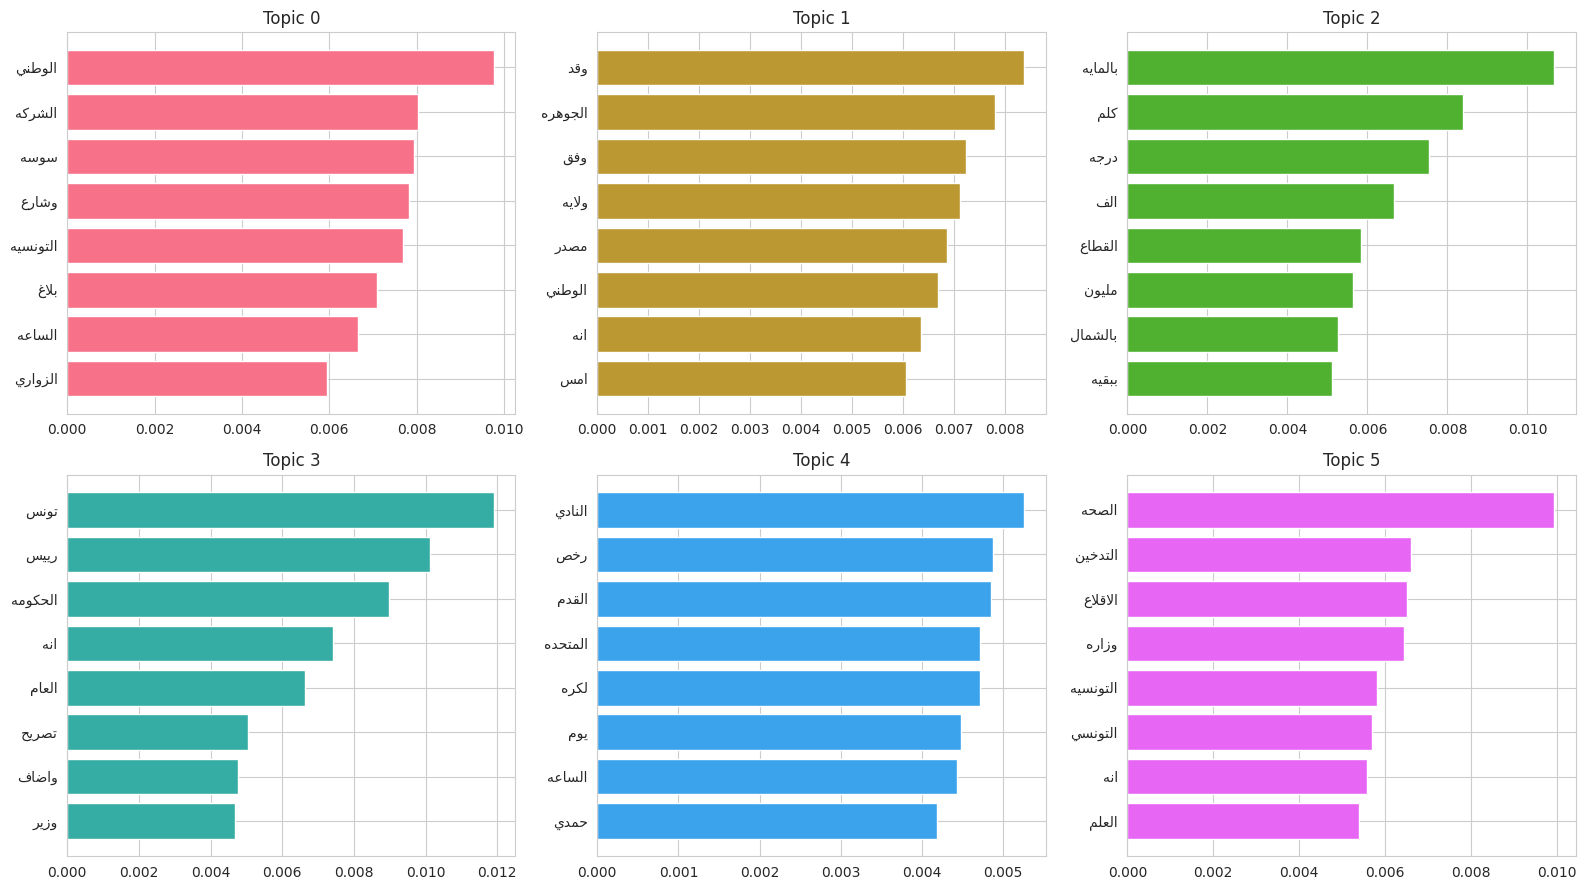

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i in range(NUM_TOPICS):
    terms = lda_model.show_topic(i, topn=8)
    words = [ar(w) for w, _ in terms]
    weights = [v for _, v in terms]
    axes[i].barh(words, weights, color=sns.color_palette("husl", NUM_TOPICS)[i])
    axes[i].set_title(f"Topic {i}")
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

In [55]:
locations = set('''
تونس فرنسا مصر ليبيا الجزائر المغرب السعوديه الامارات قطر الكويت الاردن
لبنان سوريا العراق فلسطين اليمن السودان امريكا الولايات المتحده روسيا الصين
بريطانيا المانيا ايطاليا اسبانيا تركيا ايران باريس القاهره الرباط الرياض
دبي بيروت بغداد دمشق طرابلس واشنطن لندن برلين موسكو بكين
'''.split())

org_keywords = ["وزاره", "مركز", "منظمه", "حزب", "جامعه", "حكومه", "برلمان", "نقابه", "مؤسسه", "هيئه", "لجنه", "بنك"]
person_titles = ["رئيس", "وزير", "سفير", "نائب", "مدير", "الرئيس", "السيد", "الدكتور"]

def extract_entities(text):
    tokens = str(text).split()
    entities = {"LOCATION": [], "ORG": [], "PERSON": []}

    for i, token in enumerate(tokens):
        if token in locations:
            entities["LOCATION"].append(token)
        if token in org_keywords and i + 1 < len(tokens):
            entities["ORG"].append(f"{token} {tokens[i+1]}")
        if token in person_titles and i + 1 < len(tokens):
            entities["PERSON"].append(f"{token} {tokens[i+1]}")

    return entities

In [56]:
all_locations, all_orgs, all_persons = [], [], []

for text in df["clean_text_no_stem"]:
    ents = extract_entities(text)
    all_locations.extend(ents["LOCATION"])
    all_orgs.extend(ents["ORG"])
    all_persons.extend(ents["PERSON"])

print("Total locations found:", len(all_locations))
print("Total orgs found:", len(all_orgs))
print("Total persons found:", len(all_persons))

Total locations found: 7647
Total orgs found: 3060
Total persons found: 1373


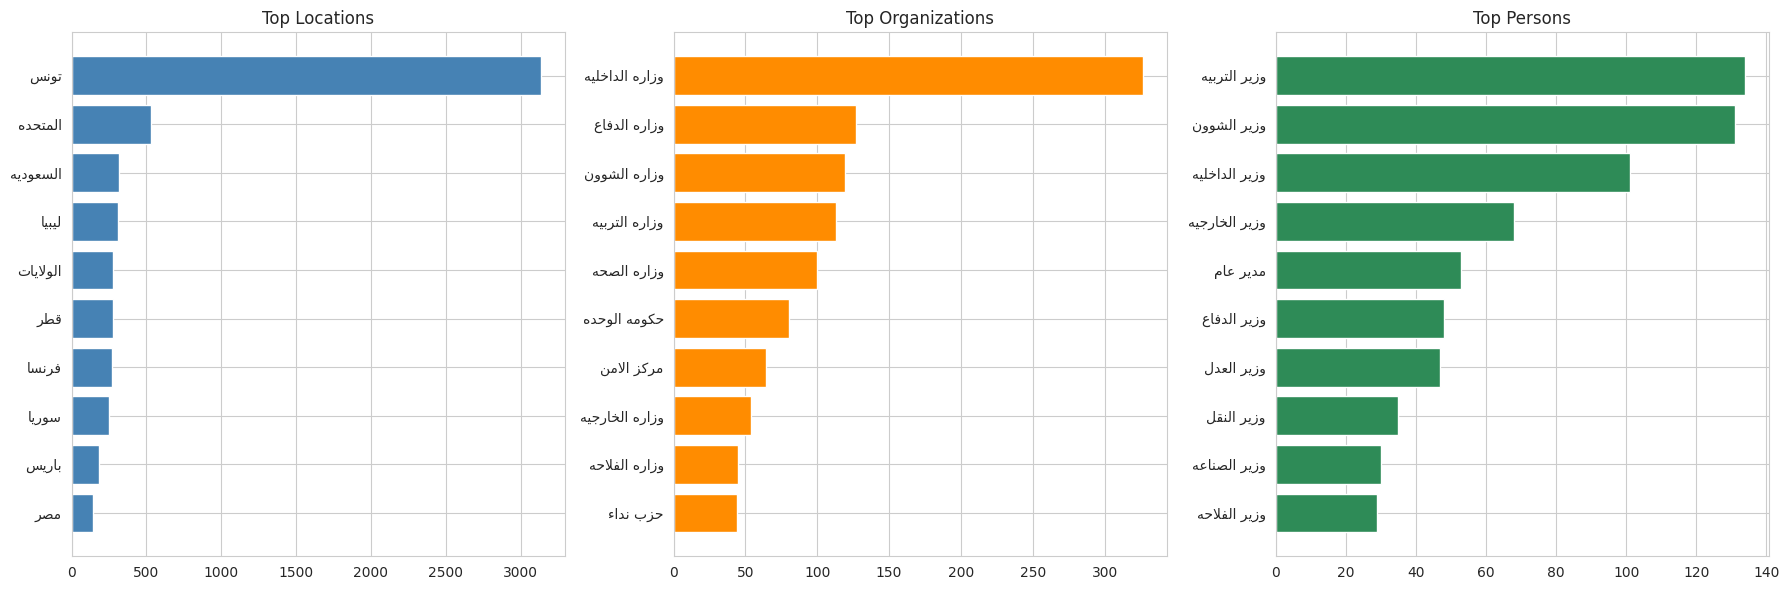

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, data, title, color in zip(
    axes,
    [all_locations, all_orgs, all_persons],
    ["Top Locations", "Top Organizations", "Top Persons"],
    ["steelblue", "darkorange", "seagreen"]
):
    top = Counter(data).most_common(10)
    if top:
        words, counts = zip(*top)
        ax.barh([ar(w) for w in words], counts, color=color)
        ax.invert_yaxis()
        ax.set_title(title)

plt.tight_layout()
plt.show()

In [58]:
def analyze_text(raw_text):
    # تنظيف
    cleaned_steps = remove_diacritics(raw_text)
    cleaned_steps = remove_tatweel(cleaned_steps)
    cleaned_steps = normalize_arabic(cleaned_steps)
    cleaned_steps = keep_arabic_only(cleaned_steps)
    tokens = [w for w in cleaned_steps.split() if w not in all_stopwords and len(w) > 2]
    clean = " ".join(tokens)

    # تصنيف الفئة
    vec = tfidf2.transform([clean])
    pred_category = le.inverse_transform(svm_model2.predict(vec))[0]

    # المشاعر
    score = sentiment_score(clean)
    label = sentiment_label(score)

    # الكيانات
    ents = extract_entities(clean)

    # التلخيص
    summary = textrank_summarize(raw_text, num_sentences=2)

    return {
        "predicted_category": pred_category,
        "sentiment": label,
        "sentiment_score": round(score, 3),
        "entities": ents,
        "summary": summary
    }

for i in [0, 5, 20]:
    result = analyze_text(df["original_text"].iloc[i])
    print(f"--- Article {i} (true category: {df['category'].iloc[i]}) ---")
    for k, v in result.items():
        print(f"{k}: {v}")
    print()

--- Article 0 (true category: culture) ---
predicted_category: culture
sentiment: Positive
sentiment_score: 1.0
entities: {'LOCATION': ['مصر', 'فلسطين', 'سوريا', 'تونس', 'تونس', 'تونس', 'تونس', 'تونس', 'تونس', 'تونس', 'تونس', 'تونس', 'تونس'], 'ORG': [], 'PERSON': []}
summary: أشرف رئيس الجمهورية الباجي قايد السبسي اليوم بقصر قرطاج على موكب منح الوسام الوطني للاستحقاق الثقافي لثلّة من الفنانين والمبدعين و ذلك بمناسبة انعقاد أيام قرطاج السينمائية. والفنانون هم : *الصنف الأوّل: - عبد الرحمان سيساكو (موريتانيا) - جميل راتب (مصر) - ميشال خليفي (فلسطين) - ادريسا ودراغو (بوركينا فاسو) - محمد ملص (سوريا) - رضا الباهي (تونس: تعذّر عليه الحضور) - عمر الخليفي (تونس) *الصنف الثاني: - عبد العزيز بن ملوكة (تونس) - نجيب عيّاد (تونس) - منصف شرف الدين (تونس: تعذّر عليه الحضور) *الصنف الثالث: - ابراهيم اللطيّف (تونس) - خميس الخياطي (تونس: تعذّر عليه الحضور) - درّة زرّوق (تونس: تعذّر عليها الحضور) - شوقي الماجري (تونس) *الصنف الرابع: - كوثر بن هنيّة (تونس)

--- Article 5 (true category: culture) ---
pred

/tmp/ipykernel_4285/1784770717.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Score", y="Component", data=final_master_table, palette="mako")


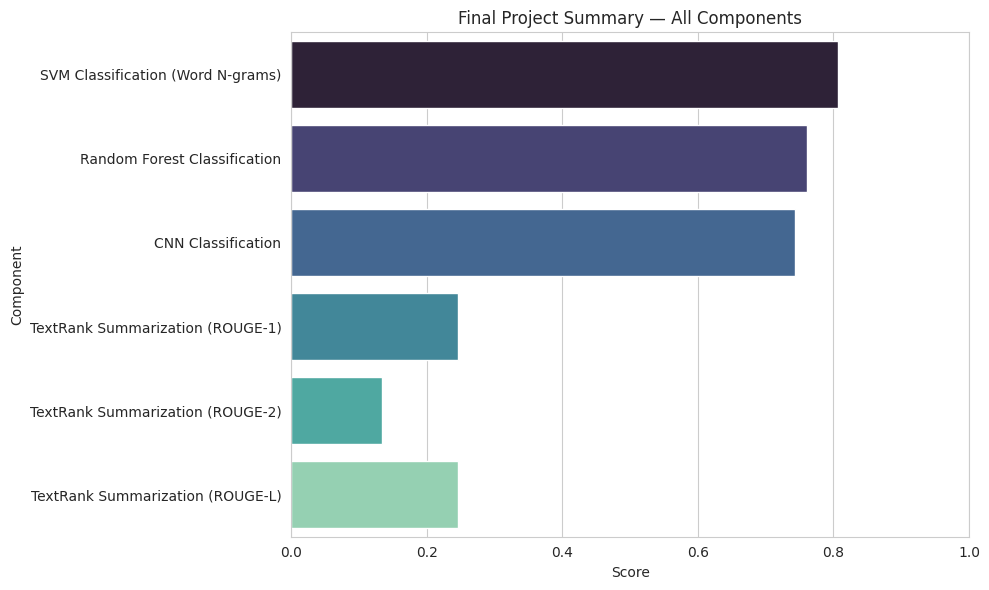

,Component,Score
0,SVM Classification (Word N-grams),0.806331
1,Random Forest Classification,0.761018
2,CNN Classification,0.743017
3,TextRank Summarization (ROUGE-1),0.246781
4,TextRank Summarization (ROUGE-2),0.133714
5,TextRank Summarization (ROUGE-L),0.246245


In [59]:
final_master_table = pd.DataFrame({
    "Component": [
        "SVM Classification (Word N-grams)",
        "Random Forest Classification",
        "CNN Classification",
        "TextRank Summarization (ROUGE-1)",
        "TextRank Summarization (ROUGE-2)",
        "TextRank Summarization (ROUGE-L)",
    ],
    "Score": [
        svm_accuracy2,
        rf_accuracy,
        cnn_accuracy,
        np.mean(rouge1_scores),
        np.mean(rouge2_scores),
        np.mean(rougeL_scores),
    ]
})

plt.figure(figsize=(10, 6))
sns.barplot(x="Score", y="Component", data=final_master_table, palette="mako")
plt.title("Final Project Summary — All Components")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

final_master_table